In [3]:
import torch 
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def torch_cart2sph(pos):
    # Extract x, y, z components
    x = pos[:, 0]
    y = pos[:, 1]
    z = pos[:, 2]

    # Compute spherical coordinates
    hxy = torch.hypot(x, y)
    r = torch.hypot(hxy, z)
    el = torch.atan2(z, hxy)
    az = torch.atan2(y, x)

    # Concatenate azimuth, elevation, and radius
    spherical = torch.stack((az, el, r), dim=1)

    return spherical

In [7]:
def torch_sph2cart(pos):
    # Extract az, el, r components
    az = pos[:, 0]
    el = pos[:, 1]
    r = pos[:, 2]

    rcos_theta = r * torch.cos(el)
    x = rcos_theta * torch.cos(az)
    y = rcos_theta * torch.sin(az)
    z = r * torch.sin(el)

    # Concatenate x, y, and z
    cartesian = torch.stack((x, y, z), dim=1)

    return cartesian

In [22]:
trunk_0 = torch.tensor([[0.0, 0.0, 0.3],[0.0, 0.0, 0.3]])

In [23]:
trunk_tg = torch.tensor([[0.0572, -0.1852, 0.3000], [0.1906, 0.1908, 0.3000]])

In [34]:
trunk_lo = torch.tensor([[0.0339, -0.1097, 0.2772], [0.0811, 0.0812, 0.2772]])

In [35]:
torch_cart2sph(trunk_tg)

tensor([[-1.2712,  0.9972,  0.3572],
        [ 0.7859,  0.8386,  0.4034]])

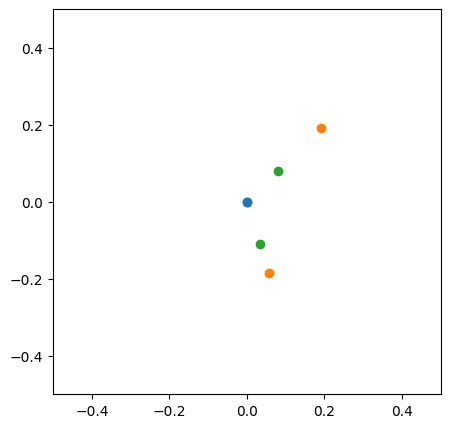

In [36]:
plt.figure(figsize=(5,5))
plt.xlim(-0.5, 0.5)
plt.ylim(-0.5, 0.5)
plt.scatter(trunk_0[:, 0], trunk_0[:, 1])
plt.scatter(trunk_tg[:, 0], trunk_tg[:, 1])
plt.scatter(trunk_lo[:, 0], trunk_lo[:, 1])